## Šiame faile pateikiama *Yi-Peng 3* atvejo analizė

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, timezone

plt.style.use('bmh')
plt.rcParams['axes.facecolor'] = 'white'

In [3]:
df = pd.read_csv(
    '../data/414270000_20241118_sample(in).csv',
    parse_dates=['position_timestamp']
).set_index('position_timestamp')

df.head()

,created_at,static_timestamp,mmsi,latitude,longitude,speed,course,heading,imo,name,...,flag,draught,ship_type_code,ship_type,length,width,eta,destination,status,collection_type
position_timestamp,,,,,,,,,,,,,,,,,,,,,
2024-11-18 00:01:53+00:00,2024-11-18 00:17:52.000000 UTC,2024-11-17 23:57:56.000000 UTC,414270000,55.926158,17.388000,6.7,255.0,254,9224984,YI PENG 3,...,CN,14.5,70,DRY_BULK,224,32,2024-12-02 20:00:00.000000 UTC,PSD.EG,0,dynamic_classA
2024-11-18 00:03:30+00:00,2024-11-18 01:17:22.000000 UTC,2024-11-17 23:57:56.000000 UTC,414270000,55.925418,17.383202,6.8,255.1,255,9224984,YI PENG 3,...,CN,14.5,70,DRY_BULK,224,32,2024-12-02 20:00:00.000000 UTC,PSD.EG,0,dynamic_classA
2024-11-18 00:13:26+00:00,2024-11-18 00:21:25.000000 UTC,2024-11-18 00:09:56.000000 UTC,414270000,55.920237,17.349243,7.3,254.0,255,9224984,YI PENG 3,...,CN,14.5,70,DRY_BULK,224,32,2024-12-02 20:00:00.000000 UTC,PSD.EG,0,dynamic_classA
2024-11-18 00:17:03+00:00,2024-11-18 00:17:52.000000 UTC,2024-11-18 00:09:56.000000 UTC,414270000,55.918247,17.336458,7.3,254.4,255,9224984,YI PENG 3,...,CN,14.5,70,DRY_BULK,224,32,2024-12-02 20:00:00.000000 UTC,PSD.EG,0,dynamic_classA
2024-11-18 00:28:26+00:00,2024-11-18 00:41:56.000000 UTC,2024-11-18 00:21:56.000000 UTC,414270000,55.912168,17.296732,7.4,256.2,257,9224984,YI PENG 3,...,CN,14.5,70,DRY_BULK,224,32,2024-12-02 20:00:00.000000 UTC,PSD.EG,0,dynamic_classA


In [4]:
df_int = df.resample('15s')\
    ['latitude', 'longitude', 'speed', 'course', 'heading']\
    .median()\
    .interpolate('pchip')

In [5]:
from scipy.signal import periodogram

In [6]:
import numpy as np

In [7]:
df.columns

Index(['created_at', 'static_timestamp', 'mmsi', 'latitude', 'longitude',
       'speed', 'course', 'heading', 'imo', 'name', 'call_sign', 'flag',
       'draught', 'ship_type_code', 'ship_type', 'length', 'width', 'eta',
       'destination', 'status', 'collection_type'],
      dtype='object')

### COG kintamasis

Kursas virš žemės nuo 00:00 iki maždaug 02:30 UTC svyravo (euristiškai, vizualiai).
Tai galime interpretuoti per fizinę prizmę:

Laivą, tempiantį inkarą jūros dugnu, veikia panačios jėgos, kaip laivą, tempiamą laivo-vilkiko.

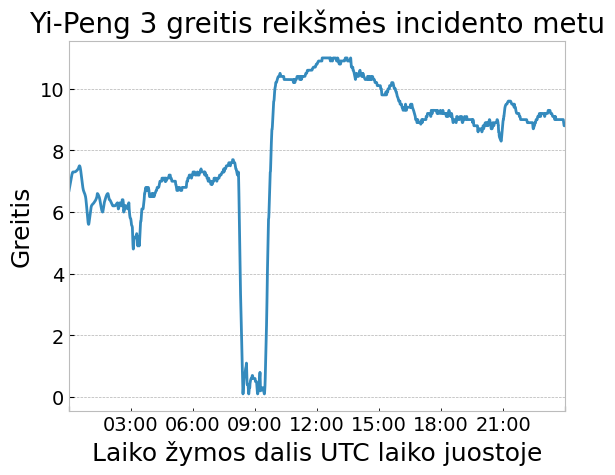

In [8]:
df_int['speed'].plot()

plt.xlabel('Laiko žymos dalis UTC laiko juostoje', size=18)
plt.ylabel('Greitis', size=18)
plt.tick_params(axis='both', which='both', labelsize=14)

plt.title('Yi-Peng 3 greitis reikšmės incidento metu', size=20)

plt.savefig('sog-anomaly.png', dpi=750)

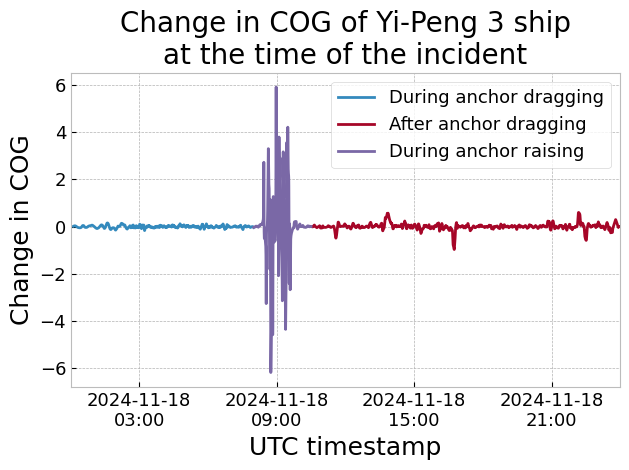

In [18]:
data_feat = df_int['course']\
    .apply(lambda x: 180 - np.abs(180 - x))\
    .diff(1)\
    .rolling(25)\
    .mean()

anchor_raise_start = datetime(2024,11,18,8,0, tzinfo=timezone.utc)
anchor_raise_end = datetime(2024,11,18,10,30, tzinfo=timezone.utc)

fig, ax = plt.subplots()

data_feat\
    .loc[:anchor_raise_start]\
    .plot(label='During anchor dragging', ax=ax)

data_feat\
    .loc[anchor_raise_end:]\
    .plot(label='After anchor dragging', ax=ax)

data_feat\
    .loc[anchor_raise_start:anchor_raise_end]\
    .plot(label='During anchor raising', ax=ax)

ax.set_xlabel('UTC timestamp', size=18)
ax.set_ylabel('Change in COG', size=18)
ax.set_title('Change in COG of Yi-Peng 3 ship\nat the time of the incident', size=20)

ax.set_xticks(
    ticks=[datetime(2024,11,18, 3+x*6,0) for x in range(0, 4)],
    labels=[f"2024-11-18\n{(3+x*6):02}:00" for x in range(0, 4)],
    minor=False
)
ax.set_xticks(
    ticks=[],
    labels=[],
    minor=True
)
ax.tick_params(axis='both', which='both', labelsize=13)
ax.legend(fontsize=13)

plt.tight_layout()
plt.savefig('cog-pokytis.png', dpi=750)
plt.show()

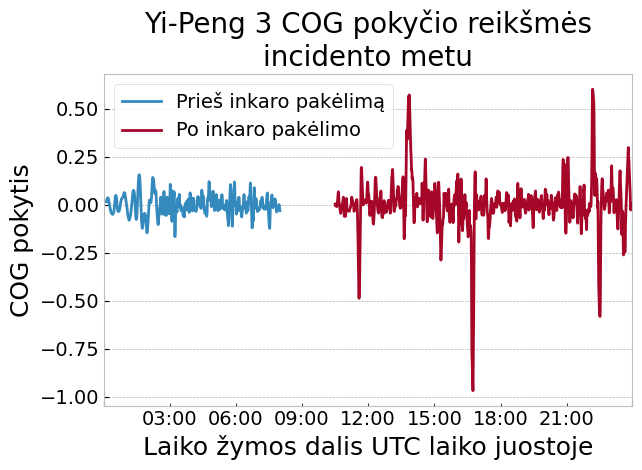

In [24]:
data_feat = df_int['course']\
    .apply(lambda x: 180 - np.abs(180 - x))\
    .diff(1)\
    .rolling(25)\
    .mean()

anchor_raise_start = datetime(2024,11,18,8,0, tzinfo=timezone.utc)
anchor_raise_end = datetime(2024,11,18,10,30, tzinfo=timezone.utc)

data_feat\
    .loc[:anchor_raise_start]\
    .plot(label='Prieš inkaro pakėlimą')

data_feat\
    .loc[anchor_raise_end:]\
    .plot(label='Po inkaro pakėlimo')

# data_feat\
#     .loc[anchor_raise_start:anchor_raise_end]\
#     .plot(label='Inkaro pakėlimas')

plt.xlabel('Laiko žymos dalis UTC laiko juostoje', size=18)
plt.ylabel('COG pokytis', size=18)
plt.title('Yi-Peng 3 COG pokyčio reikšmės\nincidento metu', size=20)

plt.tick_params(axis='both', which='both', labelsize=14)
plt.legend(fontsize=14)

plt.tight_layout()
plt.savefig('cog-pokytis.png', dpi=750)
plt.show()

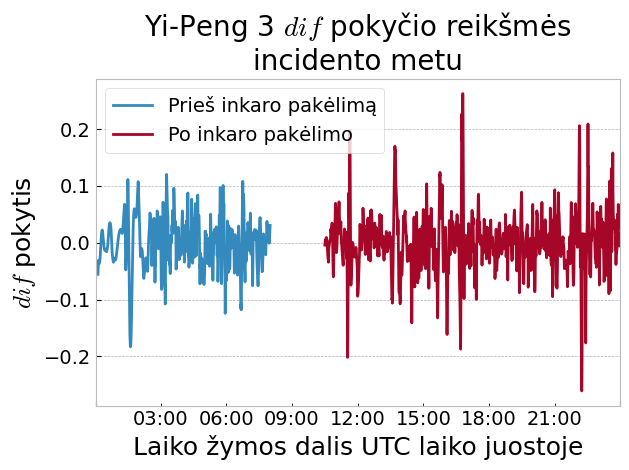

In [28]:
df_int['dif'] = (df_int['course'] - df_int['heading'] + 180) % 360 - 180

data_feat = df_int['dif']\
    .diff(1)\
    .rolling(25)\
    .mean()

anchor_raise_start = datetime(2024,11,18,8,0, tzinfo=timezone.utc)
anchor_raise_end = datetime(2024,11,18,10,30, tzinfo=timezone.utc)

data_feat\
    .loc[:anchor_raise_start]\
    .plot(label='Prieš inkaro pakėlimą')

data_feat\
    .loc[anchor_raise_end:]\
    .plot(label='Po inkaro pakėlimo')


# data_feat\
#     .loc[anchor_raise_start:anchor_raise_end]\
#     .plot(label='Inkaro pakėlimo momentas')
    

plt.xlabel('Laiko žymos dalis UTC laiko juostoje', size=18)
plt.ylabel('$dif$ pokytis', size=18)
plt.title('Yi-Peng 3 $dif$ pokyčio reikšmės\nincidento metu', size=20)

plt.tick_params(axis='both', which='both', labelsize=14)
plt.legend(fontsize=14)

plt.tight_layout()
plt.savefig('dif-pokytis.png', dpi=750)
plt.show()


In [8]:
import os

In [9]:
file_names = os.listdir('../data/yipeng')

df = pd.concat([
    pd.read_csv(
        f'../data/yipeng/{file_name}',
        parse_dates=['# Timestamp'],
        dayfirst=True
    )\
        .drop(columns=['Unnamed: 0'])
    for file_name in file_names
])

### Panašumą tikrinsime taip: jei nuo kirtimo taško yra mažiau nei vienetas

2024-11-18 09:00 -> (55.691, 15.8)

In [10]:
from geopy.distance import geodesic, great_circle

In [78]:
df_int

,latitude,longitude,speed,course,heading
position_timestamp,,,,,
2024-11-18 00:01:00+00:00,55.926158,17.388000,6.7000,255.000000,254.000000
2024-11-18 00:02:00+00:00,55.925806,17.385720,6.7500,255.069167,254.645833
2024-11-18 00:03:00+00:00,55.925418,17.383202,6.8000,255.100000,255.000000
2024-11-18 00:04:00+00:00,55.924982,17.380352,6.8545,255.069200,255.000000
2024-11-18 00:05:00+00:00,55.924509,17.377253,6.9160,254.985600,255.000000
...,...,...,...,...,...
2024-11-18 23:55:00+00:00,54.625642,12.333693,8.9000,235.000000,232.000000
2024-11-18 23:56:00+00:00,54.623973,12.329605,8.8000,234.800000,232.000000
2024-11-18 23:57:00+00:00,54.621658,12.323955,8.8000,235.000000,232.000000


In [97]:
df.shape[0]

5973829

In [80]:
close_to_drift_point = df.apply(
    lambda row: geodesic( (row['Latitude'], row['Longitude']), (55.926, 17.388) ).meters < 1000,
    axis='columns'
)
df[close_to_drift_point].to_csv('close_to_drift.csv')

In [83]:
df_close = pd.read_csv(
    'close_to_drift.csv',
    parse_dates=['# Timestamp']
)\
    .drop(columns='Unnamed: 0')

In [86]:
df_close[['# Timestamp', 'MMSI']]

,# Timestamp,MMSI
0,2026-01-19 09:00:09,210731000
1,2026-01-19 14:18:11,538010426
2,2026-01-19 14:18:50,538010426
3,2026-01-19 14:19:11,538010426
4,2026-01-19 14:19:40,538010426
5,2026-01-19 14:20:11,538010426
6,2026-01-19 14:20:20,538010426
7,2026-01-19 14:20:50,538010426
8,2026-01-19 14:21:20,538010426
9,2026-01-19 14:21:40,538010426


<Axes: xlabel='# Timestamp'>

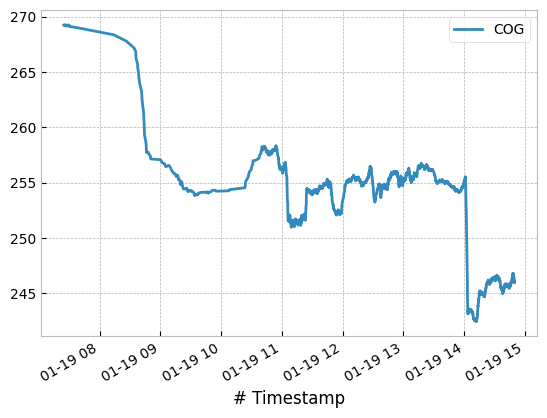

In [95]:
df_similar = df[
    (df['# Timestamp'].dt.normalize() == '2026-01-19') &
    (df['MMSI'] == 210731000)
].sort_values('# Timestamp')

df_similar['COG'] = df_similar['COG']\
    .rolling(20)\
    .mean()

df_similar.plot(x='# Timestamp', y='COG')

<Axes: xlabel='# Timestamp'>

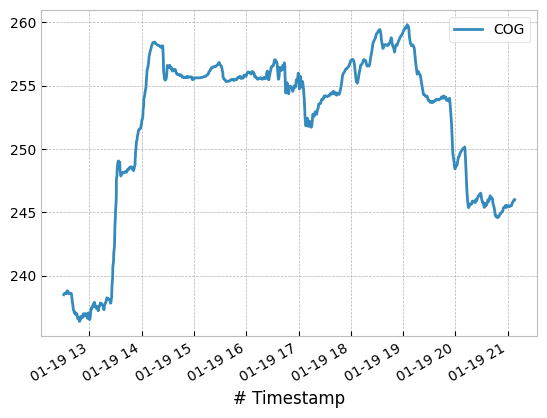

In [94]:
df_similar = df[
    (df['# Timestamp'].dt.normalize() == '2026-01-19') &
    (df['MMSI'] == 538010426)
].sort_values('# Timestamp')

df_similar['COG'] = df_similar['COG']\
    .rolling(20)\
    .mean()

df_similar.plot(x='# Timestamp', y='COG')